In [1]:
import warnings

import numpy as np
import pandas as pd
import pypsa

from pathlib import Path

import pytz
from itertools import product

from congestion.data import simbench_data

/home/carl-wanninger/anaconda3/envs/grecco_sim/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## Topology

In [2]:
data_root = Path("/home/carl-wanninger/data/")

n = pypsa.Network()
 
n_feeders = 2
user_per_feeder = 3
 
slack_bus = {"name": "Slack", "v_nom": 10.0}
lv_main_bus = {"name": "LV main bus", "v_nom": 0.4}

def user_bus(user_id: int, feeder_id: int) -> str:
    return f"Bus User{user_id} at Feeder{feeder_id}"

user = [{"name": user_bus(i, j), "v_nom": 0.4}
        for i, j in product(range(user_per_feeder), range(n_feeders))]

for bus in [slack_bus, lv_main_bus] + user:
    n.add(class_name="Bus", **bus)
    
print(n.buses)

slack_generator = {"name": "ExternalGrid", "bus": "Slack", "control": "Slack"}
n.add(class_name="Generator", **slack_generator)

trafo_type = "0.4 MVA 10/0.4 kV"
bus0, bus1 = slack_bus["name"], lv_main_bus["name"]
transformer = {"name": "MV/LV Transformer", "bus0": bus0, "bus1": bus1, "type": trafo_type}
n.add(class_name="Transformer", **transformer)

line_type = "NAYY 4x150 SE"
length = 0.1  # km

for feeder in range(n_feeders):
    feeder_start = {"name": f"Feeder {feeder} - 0", "bus0": lv_main_bus["name"], "bus1": user_bus(0, feeder)}
    lines = [feeder_start]
    
    for user in range(1, user_per_feeder):
        feeder_segment = {"name": f"Feeder {feeder} - {user}",
                          "bus0": user_bus(user - 1, feeder),
                          "bus1": user_bus(user, feeder)}
        lines.append(feeder_segment)

    for line in lines:
        n.add(class_name="Line", type=line_type, length=length, **line)

attribute             v_nom type    x    y carrier unit  v_mag_pu_set  \
Bus                                                                     
Slack                  10.0       0.0  0.0      AC                1.0   
LV main bus             0.4       0.0  0.0      AC                1.0   
Bus User0 at Feeder0    0.4       0.0  0.0      AC                1.0   
Bus User0 at Feeder1    0.4       0.0  0.0      AC                1.0   
Bus User1 at Feeder0    0.4       0.0  0.0      AC                1.0   
Bus User1 at Feeder1    0.4       0.0  0.0      AC                1.0   
Bus User2 at Feeder0    0.4       0.0  0.0      AC                1.0   
Bus User2 at Feeder1    0.4       0.0  0.0      AC                1.0   

attribute             v_mag_pu_min  v_mag_pu_max control generator sub_network  
Bus                                                                             
Slack                          0.0           inf      PQ                        
LV main bus               

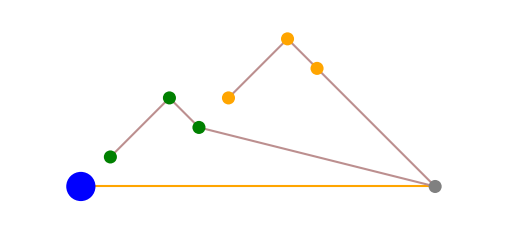

In [3]:
# Validate topology.
# Increase size of MV grid buses and add some colors.
bus_sizes = {b: 0.001 for b in n.buses.index}
bus_colors = {b: "grey" for b in n.buses.index}
bus_sizes["Slack"] = 0.005
bus_colors["Slack"] = "blue"

for bus, _ in bus_colors.items():
    if "Feeder0" in bus:
        bus_colors[bus] = "green"
    if "Feeder1" in bus:
        bus_colors[bus] = "orange"
        
        
with warnings.catch_warnings(action="ignore"):
    _ = n.plot(bus_colors=bus_colors, bus_sizes=bus_sizes, margin=0.2)

## Timeseries

In [4]:
np.random.seed(65537)

simbench_path = data_root / "simbench_csv" / "all_profiles_2034"
simbench = simbench_data.SimBenchData(simbench_path)
year, month, day = 2016, 10, 12

start = pd.Timestamp(year, month, day)
end = pd.Timestamp(year, month, day + 1)
snapshot_index = pd.date_range(start, end, freq="15min")
snapshot_index.tz_localize(pytz.UTC)

n.set_snapshots(snapshot_index)

def filter_timestamps(df: pd.DataFrame, start_time=start, end_time=end):
    return df[(df.index >= start_time) & (df.index < end_time)]

4 duplicates in RESProfile.csv were averaged. 
4 duplicates in LoadProfile.csv were averaged. 
4 duplicates in StorageProfile.csv were averaged. 


In [5]:
# Baseload
import random

random.seed(65537)


for user, feeder in product(range(user_per_feeder), range(n_feeders)):
    # Baseload data.
    bus = user_bus(user, feeder)
    
    baseload_profile = random.sample(simbench.household_tags, k=1)[0]
    baseload_data = simbench.load_t[f"{baseload_profile}_pload"] 
    baseload_data.index = pd.DatetimeIndex(baseload_data.index)
    baseload_data = filter_timestamps(baseload_data) * 0.003
    load = {"name": f"Baseload at {bus}", "bus": bus, "p_set": baseload_data}
    # Carrier information is expected by GrECCo.
    n.add(class_name="Load", carrier="inflex", **load)
    
    # PV data.
    pv_profile = random.sample(simbench.pv_tags, k=1)[0]
    pv_data = simbench.gen_t[f"{pv_profile}"]
    pv_data.index = pd.DatetimeIndex(pv_data.index)
    pv_data = filter_timestamps(pv_data) * 0.010
    generator = {"name": f"PV at {bus}", "bus": bus, "p_set": pv_data}
    n.add(class_name="Generator", carrier="solar", **generator)
    
    # Storage
    p_nom = random.sample([0.001, 0.002], 1)[0]
    storage = {"name": f"Storage at {bus}", "bus":bus, "p_nom":p_nom}
    n.add(class_name="StorageUnit", type="h0_battery", **storage)
    
    # Heat pump
    p_set = random.sample([0.002, 0.003], 1)[0]
    heat_pump = {"name": f"Heat pump at {bus}", "bus": bus, "p_set": p_set}
    n.add(class_name="Load", carrier="heat_pump", **heat_pump)
    

In [6]:
# Save grid.
sample_grid_path = data_root / "sample_grids" / "lv_minimal_1"
n.export_to_csv_folder(sample_grid_path, export_standard_types=True)

INFO:pypsa.io:Exported network lv_minimal_1 has line_types, loads, storage_units, transformer_types, buses, generators, lines, transformers


In [7]:
# Simulate Coordination (No coordination / central / fee-based)

In [8]:
# Configuration 0: Baseload

In [9]:
# Configuration 1: Baseload + PV

In [10]:
# Configuration 2: Baseload + Storage

In [11]:
# Configuration 3: Baseload + Heat pump

In [12]:
# Configuration 4: Baseload + PV + Storage

In [13]:
# Configuration 5: Baseload + PV + Heat pump

In [14]:
# Configuration 6: Baseload + Storage + Heat pump

In [15]:
# Configuration 7: Baseload + PV + Storage + Heat pump